### Global Findex Dataset Thailand EDA 
Thailand's Financial and Digital Financial Inclusion: A Comparative Analysis of Global Findex 2021 and 2024

In [32]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", context="notebook") 
plt.rcParams['figure.dpi'] = 100 
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 12)

df1 = pd.read_csv(
    'Findex Raw data_2021 (0521-0223).csv',
    encoding='latin1')

df2 = pd.read_csv('Findex Raw Data_2025 (0524-1224).csv',
                encoding='latin1')
print(df1.shape)
print(df2.shape)

(143887, 128)
(144090, 199)


In [33]:
print(df1['year'].value_counts())
print(df2['year'].value_counts())

year
2021    127854
2022     16033
Name: count, dtype: int64
year
2024    144090
Name: count, dtype: int64


In [34]:
df1.head()

,economy,economycode,regionwb,pop_adult,wpid_random,wgt,...,remittances,mobileowner,internetaccess,anydigpayment,merchantpay_dig,year
0,Afghanistan,AFG,South Asia,22647496.0,144274031,0.716416,...,5.0,1,2,1,0.0,2021
1,Afghanistan,AFG,South Asia,22647496.0,180724554,0.497408,...,5.0,1,2,0,0.0,2021
2,Afghanistan,AFG,South Asia,22647496.0,130686682,0.650431,...,3.0,2,2,0,0.0,2021
3,Afghanistan,AFG,South Asia,22647496.0,142646649,0.991862,...,5.0,1,2,0,0.0,2021
4,Afghanistan,AFG,South Asia,22647496.0,199055310,0.554940,...,5.0,2,2,0,0.0,2021


In [35]:
df2.head()

,year,economy,economycode,regionwb,pop_adult,wpid_random,...,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,2024,Nicaragua,NIC,Latin America & Caribbean (excluding high income),4830854,111111345,...,NaN,NaN,NaN,NaN,NaN,NaN
1,2024,Costa Rica,CRI,Latin America & Caribbean (excluding high income),4118576,111111579,...,NaN,NaN,NaN,NaN,NaN,NaN
2,2024,Mali,MLI,Sub-Saharan Africa (excluding high income),12725942,111112511,...,NaN,NaN,NaN,NaN,NaN,NaN
3,2024,Kuwait,KWT,High income,3950546,111113432,...,NaN,NaN,NaN,NaN,1.0,1.0
4,2024,Turkiye,TUR,Europe & Central Asia (excluding high income),66691005,111115194,...,NaN,NaN,NaN,NaN,1.0,2.0


### EDA for Findex_dataset Thailand 2021 and 2024

In [36]:
print(df1.columns.to_list())
print(df2.columns.to_list())

['economy', 'economycode', 'regionwb', 'pop_adult', 'wpid_random', 'wgt', 'female', 'age', 'educ', 'inc_q', 'emp_in', 'urbanicity_f2f', 'account', 'account_fin', 'account_mob', 'fin1_1a', 'fin1_1b', 'fin2', 'fin4', 'fin4a', 'fin5', 'fin6', 'fin7', 'fin8', 'fin8a', 'fin8b', 'fin9', 'fin9a', 'fin10', 'fin10_1a', 'fin10_1b', 'fin10_1c', 'fin10_1d', 'fin10_1e', 'fin10a', 'fin10b', 'fin11_1', 'fin11a', 'fin11b', 'fin11c', 'fin11d', 'fin11e', 'fin11f', 'fin11g', 'fin11h', 'fin13_1a', 'fin13_1b', 'fin13_1c', 'fin13_1d', 'fin13_1e', 'fin13_1f', 'fin13a', 'fin13b', 'fin13c', 'fin13d', 'fin14_1', 'fin14_2', 'fin14_2_China', 'fin14a', 'fin14a1', 'fin14b', 'fin14c', 'fin14c_2', 'fin14c_2_China', 'fin16', 'fin17a', 'fin17a1', 'fin17b', 'fin20', 'fin22a', 'fin22b', 'fin22c', 'fin24', 'fin24a', 'fin24b', 'fin26', 'fin27_1', 'fin27c1', 'fin27c2', 'fin28', 'fin29_1', 'fin29c1', 'fin29c2', 'fin30', 'fin31a', 'fin31b', 'fin31b1', 'fin31b1_China', 'fin31c', 'fin32', 'fin33', 'fin34a', 'fin34b', 'fin34d', 

In [37]:
# Select Thailand economic data from both datasets 
df1_thailand = df1[df1['economy'] == 'Thailand'].copy()
df2_thailand = df2[df2['economy'] == 'Thailand'].copy() 
print(df1_thailand.shape)
print(df2_thailand.shape)

(1017, 128)
(1000, 199)


In [38]:
print(df1_thailand['year'].value_counts())
print(df2_thailand['year'].value_counts())

year
2021    1017
Name: count, dtype: int64
year
2024    1000
Name: count, dtype: int64


In [39]:
print(set(df1_thailand.columns) - set(df2_thailand.columns))

{'remittances', 'fin8a', 'fin43e', 'fin34e', 'fin11g', 'fin9', 'fin10_1c', 'fin10_1b', 'mobileowner', 'fin13_1d', 'fin8b', 'fin27c2', 'fin10_1e', 'fin4a', 'fin14a1', 'fin39e', 'fin14c_2_China', 'fin29c1', 'fin44d', 'fin1_1b', 'fin45_1', 'fin14_1', 'fin1_1a', 'fin13_1c', 'fin44b', 'fin10b', 'fin29c2', 'fin31b1_China', 'urbanicity_f2f', 'fin27c1', 'fin14_2', 'fin44c', 'fin10_1a', 'fin10a', 'receive_pension', 'fin29_1', 'fin27_1', 'fin13_1e', 'fin42a', 'fin26', 'fin31b1', 'fin17a1', 'fin14c_2', 'fin13_1a', 'fin11h', 'fin10_1d', 'fin45_1_China', 'fin13_1b', 'fin14_2_China', 'internetaccess', 'fin44a', 'fin13_1f'}


In [40]:
print(set(df2_thailand.columns) - set(df1_thailand.columns))

{'con30c', 'con1', 'fin24d1', 'con2a', 'fin21', 'fin17d', 'fin13f', 'internet_use', 'fin19', 'fin22a_1', 'con31f', 'con28', 'con26', 'con30h', 'con2c', 'fin48d', 'con31e', 'fin22h', 'con12', 'fin49a', 'fh1', 'fin27', 'fin49b', 'con24', 'fin49e', 'con19', 'con30e', 'fin26b', 'fin36', 'con2e', 'fin13e', 'fin48e', 'con30a', 'fin25e1', 'fin17e', 'fin13f_1', 'con16', 'fin41a', 'fin48b', 'con6', 'fin47', 'con31h', 'con5', 'con31d', 'con8', 'fin49d', 'con4', 'con31a', 'fin39c', 'con13', 'fin48a', 'urbanicity', 'fin40', 'fin25e4', 'fin3', 'fin26a', 'con27', 'fh2', 'fin49c', 'fin41', 'con20', 'con30g', 'fin25e2', 'con21', 'fin17f', 'con31b', 'con22', 'receive_pensions', 'fin51', 'fin9b', 'con30f', 'fin15', 'con31c', 'con2b', 'fin34c', 'dig_account', 'fin25e3', 'fin46', 'fin22f', 'con9', 'con2g', 'fin11_2', 'con30d', 'fin11_0', 'fin14d', 'domestic_remittances', 'fin14e', 'fin24d2', 'con15', 'con31g', 'fin22g', 'fin31d', 'con18', 'con23', 'fin36a', 'con29', 'fin44', 'con11', 'fin23', 'con7', 'con

### Variables exist in both datasets

In [41]:
common_columns = list(set(df1.columns) & set(df2.columns)) 
print(len(common_columns))
print(common_columns)

76
['fin33', 'fin11e', 'fin4', 'fin16', 'year', 'fin11_1', 'fin11c', 'borrowed', 'fin17b', 'female', 'account', 'fin10', 'fin37', 'fin34a', 'fin13d', 'fin39d', 'fin13a', 'fin11a', 'age', 'fin17a', 'educ', 'receive_wages', 'pay_utilities', 'anydigpayment', 'fin7', 'fin14a', 'fin24', 'fin11b', 'fin28', 'merchantpay_dig', 'fin8', 'inc_q', 'fin31c', 'fin39a', 'fin22b', 'fin45', 'fin22a', 'fin13b', 'fin35', 'fin9a', 'fin43b', 'economycode', 'fin22c', 'pop_adult', 'receive_agriculture', 'saved', 'fin31b', 'fin43d', 'fin13c', 'fin39b', 'fin43a', 'fin34b', 'wgt', 'account_fin', 'fin30', 'fin24a', 'fin32', 'fin11f', 'fin5', 'fin2', 'fin6', 'fin14b', 'wpid_random', 'regionwb', 'fin24b', 'fin14c', 'fin20', 'fin34d', 'fin38', 'fin42', 'fin31a', 'emp_in', 'account_mob', 'economy', 'receive_transfers', 'fin11d']


In [42]:
df_thai = pd.concat([df1_thailand, df2_thailand], ignore_index=True, sort=False)
print(df_thai.shape)
print(df_thai['year'].value_counts())

(2017, 251)
year
2021    1017
2024    1000
Name: count, dtype: int64


In [43]:
df_thai.head(3)

,economy,economycode,regionwb,pop_adult,wpid_random,wgt,...,fin49c,fin49d,fin49e,fin49f,fin50,fin51
0,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,156981272,0.224081,...,NaN,NaN,NaN,NaN,NaN,NaN
1,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,195399987,0.526118,...,NaN,NaN,NaN,NaN,NaN,NaN
2,Thailand,THA,East Asia & Pacific (excluding high income),58246340.0,181150505,0.148891,...,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
df_common = df_thai[common_columns].copy()
print(df_common.shape)
print(df_common['year'].value_counts())

(2017, 76)
year
2021    1017
2024    1000
Name: count, dtype: int64


In [45]:
print(df_common.columns)

Index(['fin33', 'fin11e', 'fin4', 'fin16', 'year', 'fin11_1', 'fin11c',
       'borrowed', 'fin17b', 'female', 'account', 'fin10', 'fin37', 'fin34a',
       'fin13d', 'fin39d', 'fin13a', 'fin11a', 'age', 'fin17a', 'educ',
       'receive_wages', 'pay_utilities', 'anydigpayment', 'fin7', 'fin14a',
       'fin24', 'fin11b', 'fin28', 'merchantpay_dig', 'fin8', 'inc_q',
       'fin31c', 'fin39a', 'fin22b', 'fin45', 'fin22a', 'fin13b', 'fin35',
       'fin9a', 'fin43b', 'economycode', 'fin22c', 'pop_adult',
       'receive_agriculture', 'saved', 'fin31b', 'fin43d', 'fin13c', 'fin39b',
       'fin43a', 'fin34b', 'wgt', 'account_fin', 'fin30', 'fin24a', 'fin32',
       'fin11f', 'fin5', 'fin2', 'fin6', 'fin14b', 'wpid_random', 'regionwb',
       'fin24b', 'fin14c', 'fin20', 'fin34d', 'fin38', 'fin42', 'fin31a',
       'emp_in', 'account_mob', 'economy', 'receive_transfers', 'fin11d'],
      dtype='object')


### Renaming Columns

In [46]:
df_common_renamed = df_common.rename(columns={
        'merchantmerchantpay_dig': 'digital_merch_payment',
        'fin24a': 'emergency_fund_access',
        'fin9a':'received_acc_balance_info',
        'fin22c':'borrowed_from_savings_club',
        'borrowed':'borrowed_money',
        'fin28':'sent_domestic_remittance_account',
        'fin43b':'agri_payment_mobile',
        'fin24b':'emergency_fund_source',
        'fin20':'applied_for_mobile_loan',
        'wpid_random':'respondent_id',
        'fin31a':'utility_payment_bank',
        'fin6':'account_usage',
        'fin37':'received_goverment_transfer',
        'fin11f':'no_account_lack_of_trust',
        'fin11_1':'ever_had_bank_account',
        'saved':'saved_money',
        'fin16':'ever_had_mobile_money_account',
        'educ':'education_level',
        'fin45':'financial_health_indicator',
        'fin43a':'agri_payment_bank',
        'fin14c':'no_mobile_account_lack_documentation',
        'fin30':'made_utility_payment',
        'fin4':'debit_card_ownership',
        'wgt':'survey_weight',
        'fin31b':'utility_payment_mobile',
        'fin22a':'borrowed_from_formal_bank',
        'receive_transfers':'received_transfers',
        'fin38':'received_public_pension',
        'fin14b':'no_mobile_account_too_expensive',
        'fin17b':'saved_mobile_money',
        'account_fin':'financial_instituion_account',
        'fin11d':'no_account_insufficient_funds',
        'fin13c': 'mobile_money_usage',
        'fin5':'account_ownership', 'fin35':'high_withdrawal_fee_wages', 
        'fin13a':'mobile_money_activity',
        'year':'survey_year', 'fin24':'emergency_funds',
        'receive_agriculture':'received_agriculture_payment',
        'fin11b':'no_account_too_expensive',
        'fin34a':'wages_bank_account', 
        'fin34d':'wages_card',
        'regionwb':'world_bank_region',
        'fin33':'wage_payment_method',
        'pop_adult':'adult_population',
        'inc_q':'income_quintile',
        'fin32':'recieved_wages',
        'fin39d':'agriculture_payment_method',
        'fin14a':'no_mobile_agents_far',
        'anydigpayment':'any_digital_payment',
        'fin34b':'wages_mobile', 
        'fin7':'account_transaction_activity',
        'fin22b':'borrowed_from_family_friends',
        'fin11a':'no_account_distance',
        'fin11e':'no_account_family_member',
        'receive_wages':'received_wages',
        'fin2':'debit_card_ownership',
        'fin39b':'agricultural_payment_mobile',
        'fin43d':'agri_payment_card',
        'fin17a':'saved_bank',
        'fin11c':'no_account_documentation',
        'fin13b':'mobile_money_send_recieve',
        'emp_in':'employment_status',
        'fin31c':'utility_payment_cash',
        'fin42':'recieved_agricultural_payment',
        'account_mob':'mobile_money_account',
        'fin10':'credit_card_ownership',
        'fin8':'store_money_account',
        'fin39a':'agriculture_payment_account',
        'account':'account_ownership',
        'fin13d':'mobile_money_transaction',
        'pay_utilities':'utility_payment'})

In [47]:
# print(df_common_renamed.columns)
# df_common_renamed.head()
df_common_renamed.describe(include='all')

,wage_payment_method,no_account_family_member,debit_card_ownership,ever_had_mobile_money_account,survey_year,ever_had_bank_account,...,utility_payment_bank,employment_status,mobile_money_account,economy,received_transfers,no_account_insufficient_funds
count,982.000000,130.000000,1599.000000,1017.000000,2017.000000,110.000000,...,1422.000000,2017.000000,2017.000000,2017,2017.000000,130.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Thailand,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2017,NaN,NaN
mean,1.859470,1.753846,1.376485,1.449361,2022.487357,1.736364,...,1.607595,1.200297,0.516113,NaN,2.236490,1.707692
std,0.353527,0.778206,0.499910,0.509402,1.500319,0.762387,...,0.498441,0.400322,0.499864,NaN,1.454023,0.687047
min,1.000000,1.000000,1.000000,1.000000,2021.000000,1.000000,...,1.000000,1.000000,0.000000,NaN,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2021.000000,1.000000,...,1.000000,1.000000,0.000000,NaN,1.000000,1.000000
50%,2.000000,2.000000,1.000000,1.000000,2021.000000,2.000000,...,2.000000,1.000000,1.000000,NaN,1.000000,2.000000
75%,2.000000,2.000000,2.000000,2.000000,2024.000000,2.000000,...,2.000000,1.000000,1.000000,NaN,4.000000,2.000000


### Clearing special missing values

In [48]:
#check for missing values
print(df_common_renamed.isnull().sum())
print(df_common_renamed.isnull().mean())

wage_payment_method              1035
no_account_family_member         1887
debit_card_ownership              418
ever_had_mobile_money_account    1000
survey_year                         0
                                 ... 
employment_status                   0
mobile_money_account                0
economy                             0
received_transfers                  0
no_account_insufficient_funds    1887
Length: 76, dtype: int64
wage_payment_method              0.513138
no_account_family_member         0.935548
debit_card_ownership             0.207238
ever_had_mobile_money_account    0.495786
survey_year                      0.000000
                                   ...   
employment_status                0.000000
mobile_money_account             0.000000
economy                          0.000000
received_transfers               0.000000
no_account_insufficient_funds    0.935548
Length: 76, dtype: float64


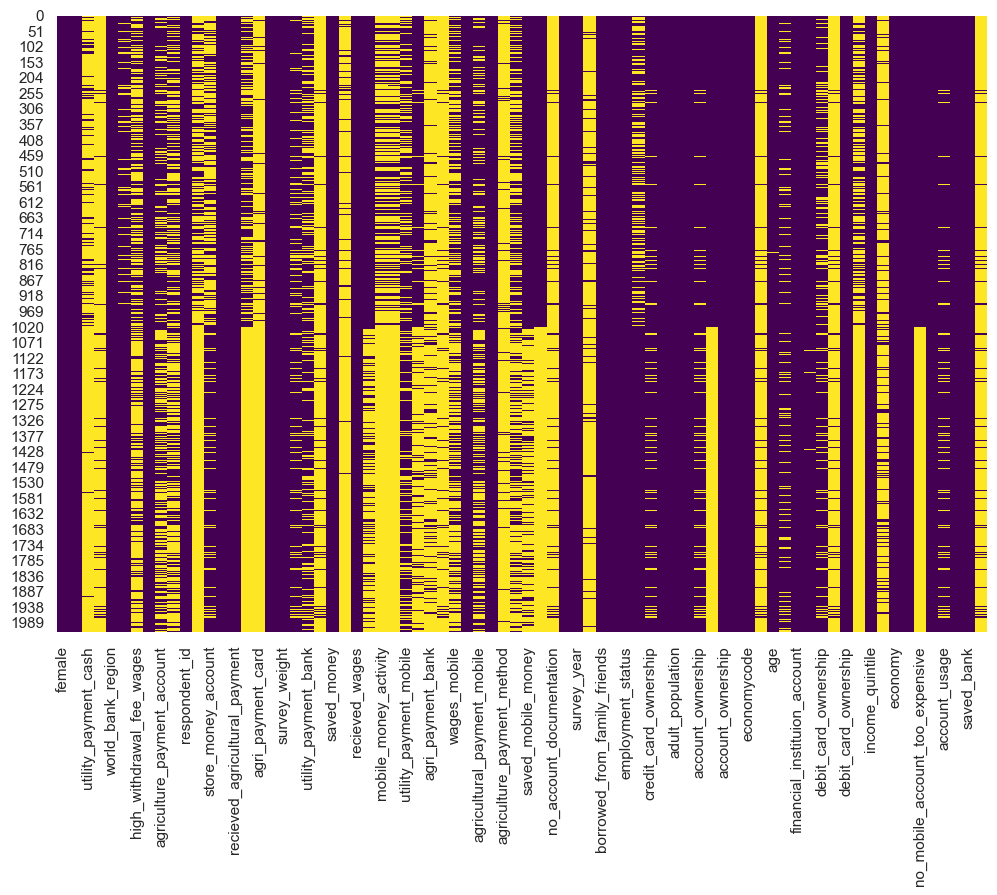

In [13]:
# visualize missing values
import seaborn as sns 
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
sns.heatmap(df_common_renamed.isnull(), cbar=False, cmap='viridis')
plt.show()

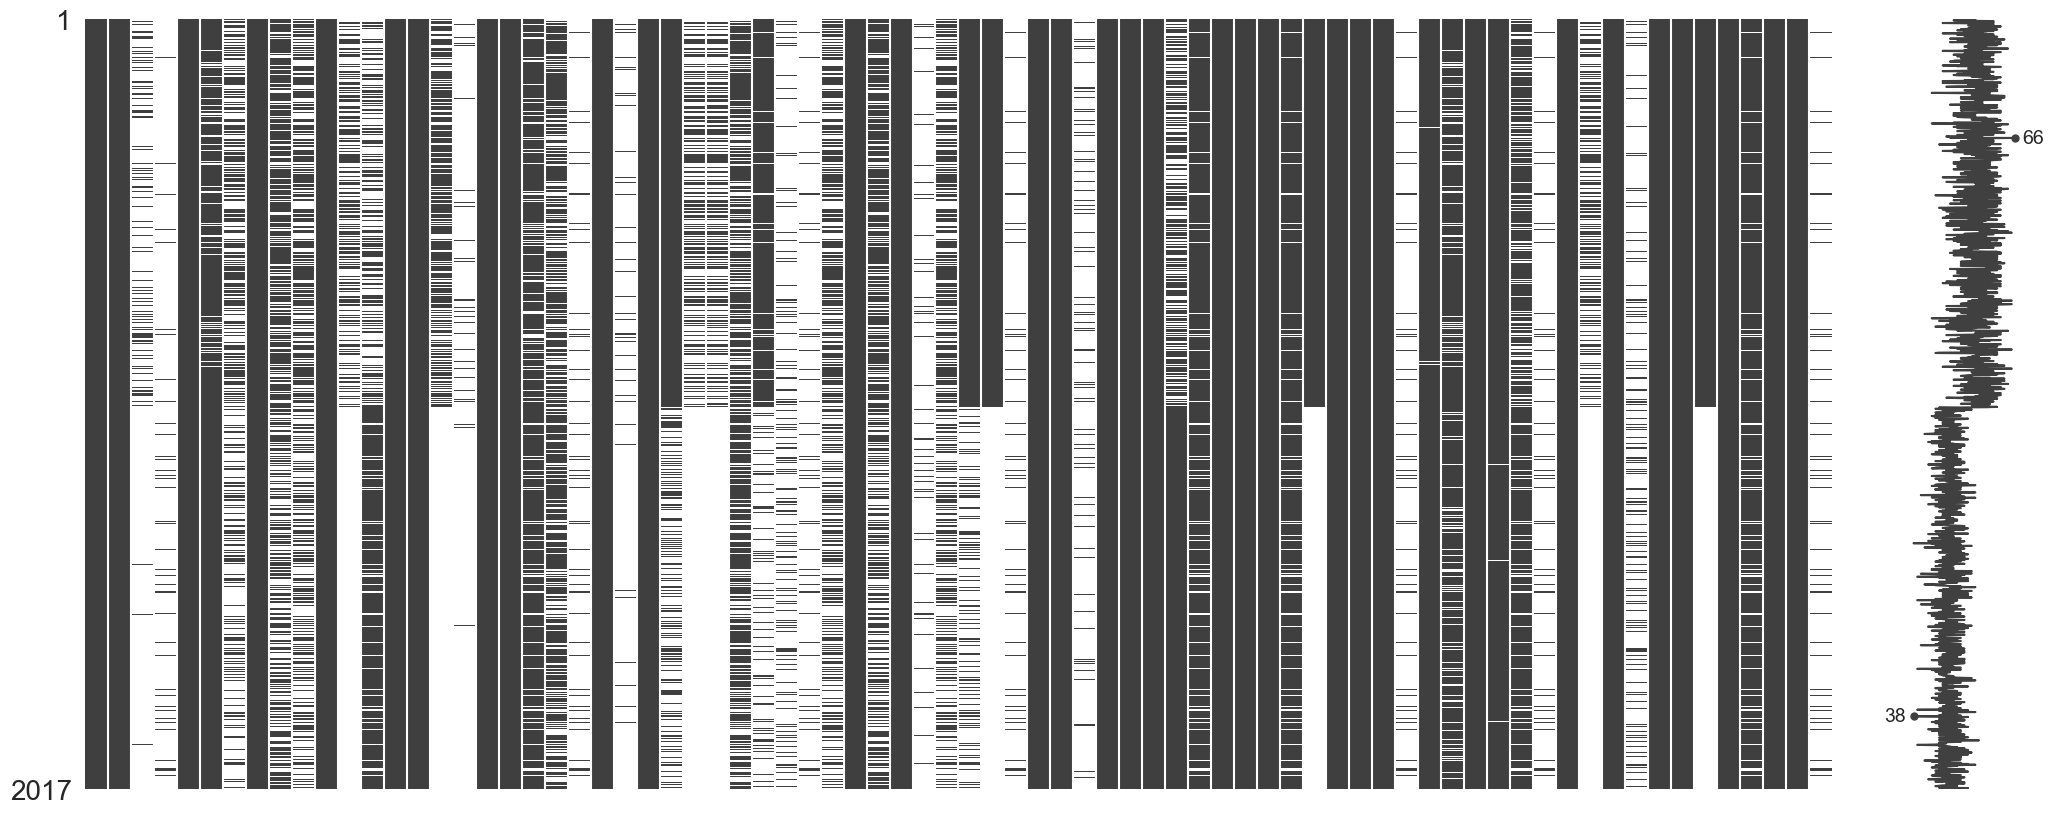

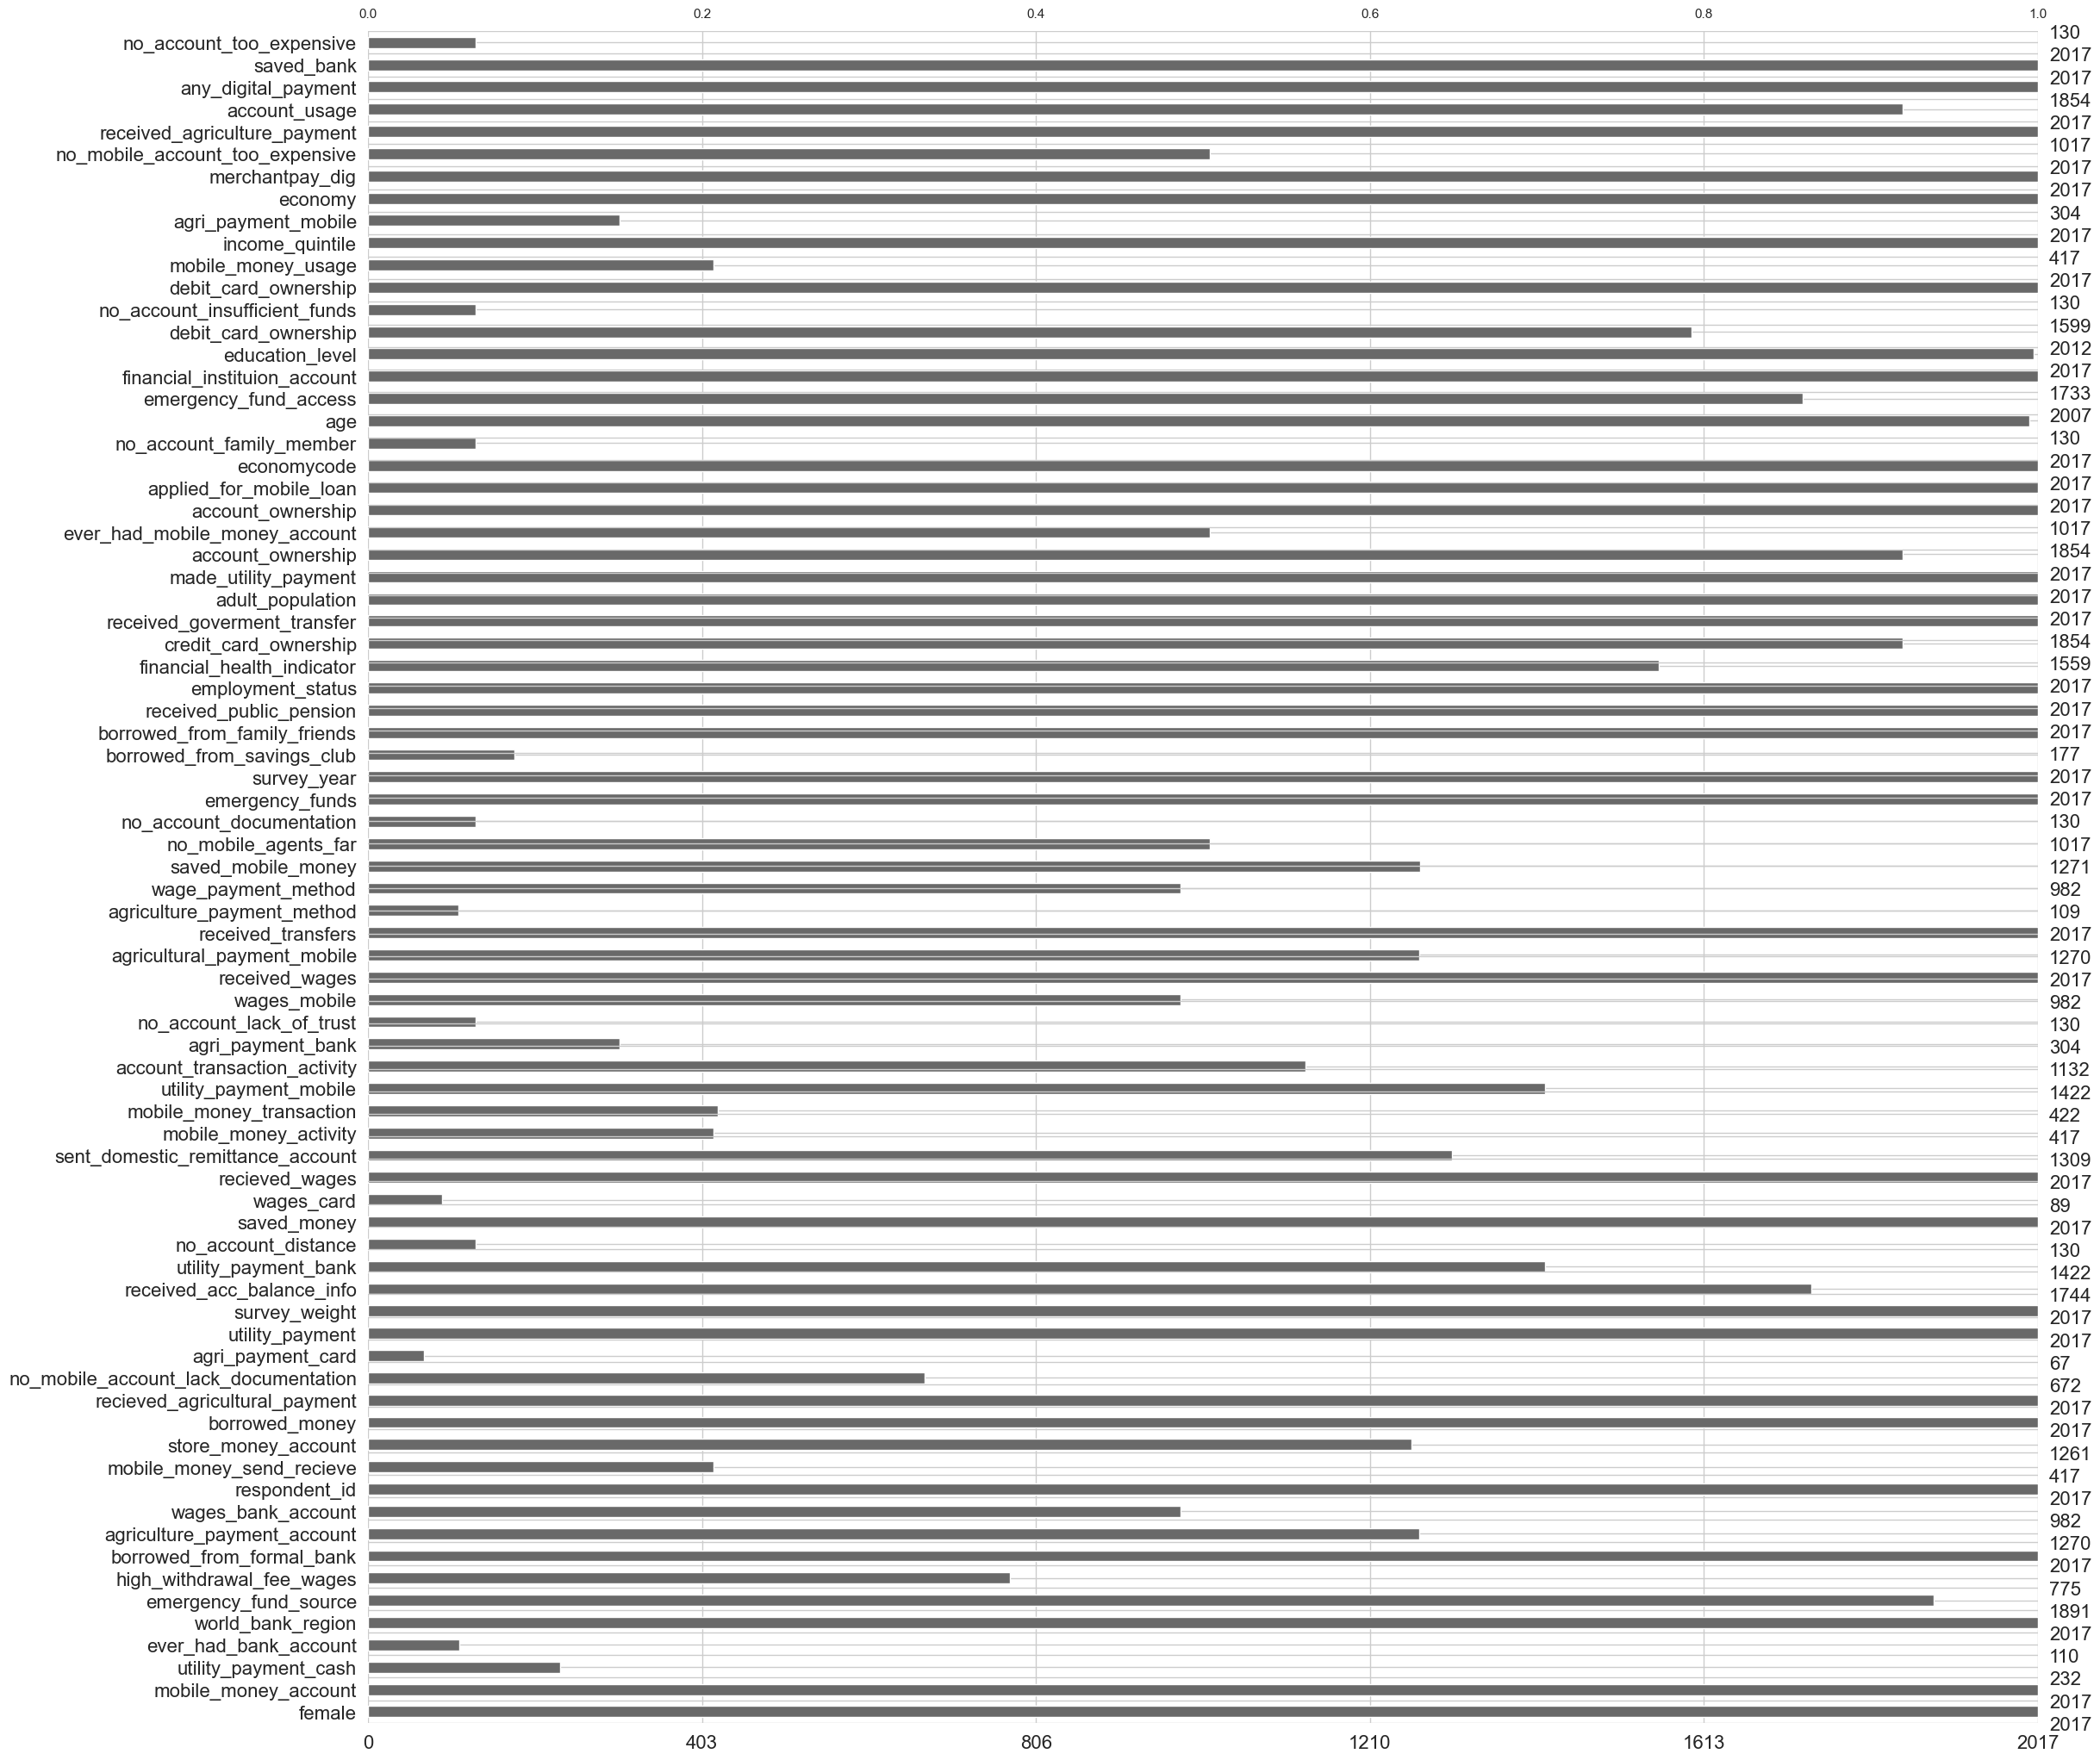

In [16]:
try:
    import missingno as msno
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "missingno"])
    import missingno as msno
msno.matrix(df_common_renamed)
plt.show()
msno.bar(df_common_renamed)
plt.show()

In [49]:
#Datasets often contain codes representing:
# Don't know # Refused # Not applicable # Miss 
codes_to_check = ["Don't know", "Refused", "Not applicable", "Miss"]
for code in codes_to_check:
    if code in df_common_renamed.values:
        print(f"Found code: {code}")
    else:
        print(f"Code not found: {code}")
print("Finished checking for codes.")

Code not found: Don't know
Code not found: Refused
Code not found: Not applicable
Code not found: Miss
Finished checking for codes.


In [50]:
df_common_renamed['codes_found'] = df_common_renamed.isin(codes_to_check).any(axis=1)
print(df_common_renamed['codes_found'].value_counts())
print("Number of rows with codes found:", df_common_renamed['codes_found'].sum())
print("Number of rows without codes found:", (~df_common_renamed['codes_found']).sum())

codes_found
False    2017
Name: count, dtype: int64
Number of rows with codes found: 0
Number of rows without codes found: 2017


In [19]:
df_common_renamed.columns.tolist()

['economycode',
 'debit_card_ownership',
 'mobile_money_transaction',
 'income_quintile',
 'account_usage',
 'utility_payment_bank',
 'wages_bank_account',
 'ever_had_bank_account',
 'account_ownership',
 'received_transfers',
 'account_ownership',
 'received_agriculture_payment',
 'no_account_insufficient_funds',
 'survey_year',
 'world_bank_region',
 'made_utility_payment',
 'age',
 'high_withdrawal_fee_wages',
 'emergency_funds',
 'debit_card_ownership',
 'agriculture_payment_account',
 'no_mobile_account_lack_documentation',
 'saved_bank',
 'no_mobile_agents_far',
 'no_account_documentation',
 'mobile_money_send_recieve',
 'merchantpay_dig',
 'survey_weight',
 'received_public_pension',
 'utility_payment_cash',
 'borrowed_from_family_friends',
 'received_goverment_transfer',
 'female',
 'no_account_family_member',
 'employment_status',
 'wages_mobile',
 'mobile_money_account',
 'sent_domestic_remittance_account',
 'any_digital_payment',
 'mobile_money_usage',
 'financial_instituion

In [51]:
print(df_common_renamed['female'].value_counts())
print(df_common_renamed['female'].dtype)

female
1    1101
2     916
Name: count, dtype: int64
int64


In [52]:
df_common_renamed["gender"] = df_common_renamed["female"].map({1:"Female", 2:"Male"})
print(df_common_renamed["gender"].value_counts())
print(df_common_renamed["gender"].dtype) 

gender
Female    1101
Male       916
Name: count, dtype: int64
object


In [53]:
print(df_common_renamed.groupby('survey_year')['income_quintile'].apply(lambda x: x.isna().sum()))
print(df_common_renamed['income_quintile'].value_counts())
print(df_common_renamed["income_quintile"].dtype)

survey_year
2021    0
2024    0
Name: income_quintile, dtype: int64
income_quintile
5.0    537
4.0    467
3.0    355
1.0    342
2.0    316
Name: count, dtype: int64
float64


In [54]:
df_common_renamed["income_quintile"] = df_common_renamed["income_quintile"].astype('Int64')
print(df_common_renamed["income_quintile"].dtype)

Int64


In [55]:
df_common_renamed["income_quintile"] = df_common_renamed["income_quintile"].map({
    1: "Q1 Lowest",
    2: "Q2",
    3: "Q3",
    4: "Q4",
    5: "Q5 Highest"
})
print(df_common_renamed["income_quintile"].value_counts())
print(df_common_renamed["income_quintile"].dtype)

income_quintile
Q5 Highest    537
Q4            467
Q3            355
Q1 Lowest     342
Q2            316
Name: count, dtype: int64
object


In [56]:
df_common_renamed["survey_year"] = df_common_renamed["survey_year"].astype('int64')

### Research Question 1 
What demographic and socioeconomic factors are associated with digital payment adoption in Thailand? 

In [57]:
df_common_renamed["any_digital_payment"].value_counts(dropna=False)

any_digital_payment
1.0    1792
0.0     225
Name: count, dtype: int64

In [58]:
df_common_renamed["any_digital_payment"].value_counts(normalize=True)*100

any_digital_payment
1.0    88.844819
0.0    11.155181
Name: proportion, dtype: float64

What Proportion of Thai Adults use Digital Payments?

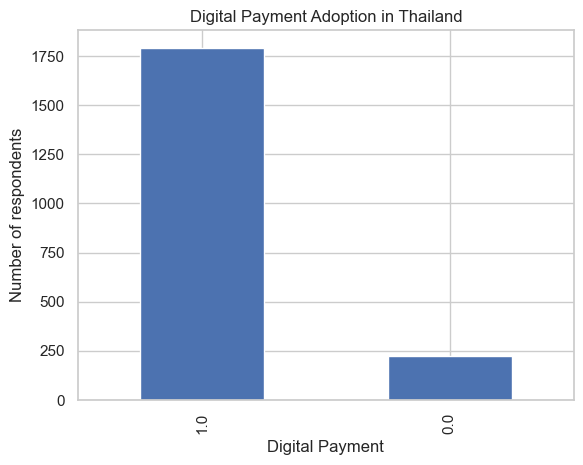

In [59]:
import matplotlib.pyplot as plt

df_common_renamed["any_digital_payment"].value_counts().plot(
    kind="bar"
)

plt.title("Digital Payment Adoption in Thailand")
plt.xlabel("Digital Payment")
plt.ylabel("Number of respondents")
plt.show()

In [29]:
print(df_common_renamed.columns.to_list())

['economycode', 'debit_card_ownership', 'mobile_money_transaction', 'income_quintile', 'account_usage', 'utility_payment_bank', 'wages_bank_account', 'ever_had_bank_account', 'account_ownership', 'received_transfers', 'account_ownership', 'received_agriculture_payment', 'no_account_insufficient_funds', 'survey_year', 'world_bank_region', 'made_utility_payment', 'age', 'high_withdrawal_fee_wages', 'emergency_funds', 'debit_card_ownership', 'agriculture_payment_account', 'no_mobile_account_lack_documentation', 'saved_bank', 'no_mobile_agents_far', 'no_account_documentation', 'mobile_money_send_recieve', 'merchantpay_dig', 'survey_weight', 'received_public_pension', 'utility_payment_cash', 'borrowed_from_family_friends', 'received_goverment_transfer', 'female', 'no_account_family_member', 'employment_status', 'wages_mobile', 'mobile_money_account', 'sent_domestic_remittance_account', 'any_digital_payment', 'mobile_money_usage', 'financial_instituion_account', 'emergency_fund_source', 'bor

### Gender Difference

In [60]:
pd.crosstab(df_common_renamed["gender"], df_common_renamed["any_digital_payment"], normalize="index")*100

any_digital_payment,0.0,1.0
gender,,
Female,12.170754,87.829246
Male,9.934498,90.065502


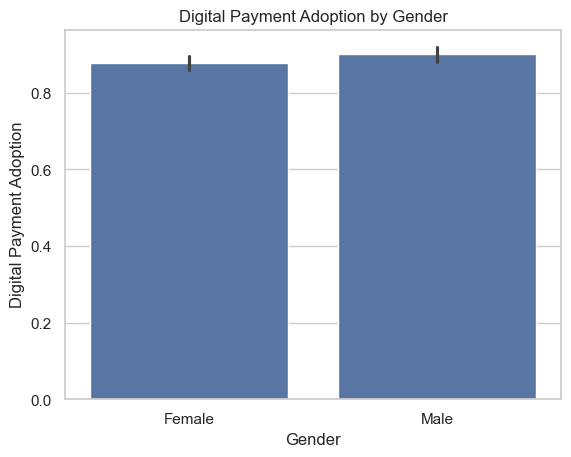

In [61]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.barplot(
    x="gender",
    y="any_digital_payment",
    data=df_common_renamed,
    estimator=lambda x: sum(x)/len(x)  # Show the proportion of digital payment adoption
)
plt.title("Digital Payment Adoption by Gender")
plt.xlabel("Gender")
plt.ylabel("Digital Payment Adoption")
plt.show()

### Chi-Square Test for Independence
- Ho: Gender and digital payment adoption are independent.
- Ha: Gender and digital payment adoption are associated. 

In [32]:
from typing import cast

import scipy.stats as stats


contingency_table = pd.crosstab(df_common_renamed["gender"], df_common_renamed["any_digital_payment"])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

alpha = 0.05

chi2, p # type: ignore

p_value = cast(float, p)

if p_value < alpha:
    print(
        "Reject the null hypothesis: There is an association "
        "between gender and digital payment adoption."
    )
else:
    print(
        "Fail to reject the null hypothesis: No significant association "
        "between gender and digital payment adoption."
    )

Fail to reject the null hypothesis: No significant association between gender and digital payment adoption.


### Age Distribution

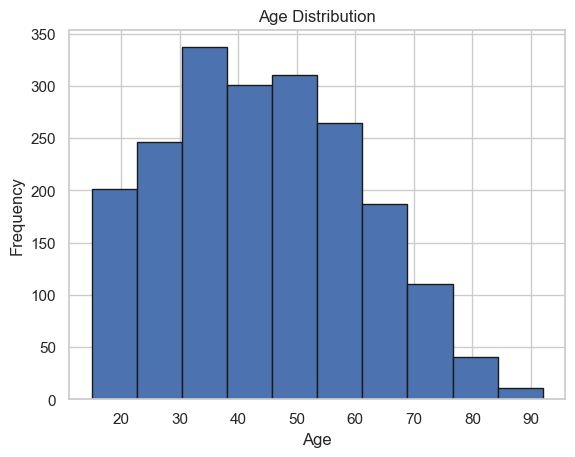

In [33]:
import matplotlib.pyplot as plt

plt.hist(df_common_renamed["age"], bins=10, edgecolor="k")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

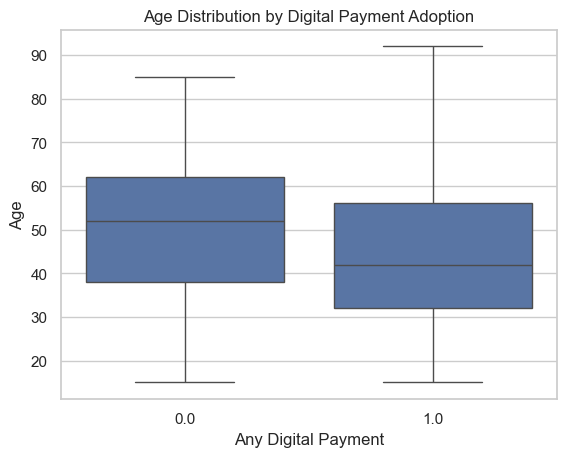

In [34]:
sns.boxplot(data = df_common_renamed, x = "any_digital_payment", y = "age")
plt.xlabel("Any Digital Payment")
plt.ylabel("Age")
plt.title("Age Distribution by Digital Payment Adoption")
plt.show()

### Interpretation of the boxplot

The boxplot compares respondents' ages according to whether they made any digital payment (`0 = No`, `1 = Yes`). The horizontal line inside each box represents the median age, while the box covers the middle 50% of observations (the interquartile range). The whiskers show the broader observed age range, excluding potential outliers.

Respondents who made digital payments have a lower median age (approximately 42 years) than respondents who did not (approximately 52 years). Their middle 50% of ages is also generally lower, suggesting that younger adults are more likely to use digital payments in this sample. However, the two distributions overlap considerably, and both groups include respondents across a wide age range. Therefore, age appears to be associated with digital-payment adoption, but this boxplot alone does not establish that age causes adoption. Other factors, such as education, income, employment, and gender, should be examined alongside age.

### t-test for Mean Age by Digital Payment Adoption

In [35]:
from scipy.stats import ttest_ind

users = df_common_renamed.loc[
    df_common_renamed["any_digital_payment"] == 1,
    "age"
].dropna()

non_users = df_common_renamed.loc[
    df_common_renamed["any_digital_payment"] == 0,
    "age"
].dropna()

t_stat, p_value = ttest_ind(
    users,
    non_users,
    equal_var=False
)

print(t_stat, p_value)

# Ho: Mean age of digital payment users = Mean age of non-digital payment users
# Ha: Mean age of digital payment users ≠ Mean age of non-digital payment users 

p_value_float = cast(float, p_value)

if p_value_float < 0.05:
    print(
        "Reject the null hypothesis: Mean age of digital payment users "
        "is different from mean age of non-digital payment users"
    )
else:
    print(
        "Fail to reject the null hypothesis: Mean age of digital payment users "
        "is not significantly different from mean age of non-digital payment users"
    )

-4.440027403890301 1.3042685800483906e-05
Reject the null hypothesis: Mean age of digital payment users is different from mean age of non-digital payment users


### Education Distribution

In [62]:
df_common_renamed["education_level"].value_counts()

education_level
1.0    878
3.0    596
2.0    522
5.0     15
4.0      1
Name: count, dtype: int64

### identify 16 problematic respondents

In [63]:
print(df_common_renamed["education_level"].value_counts(dropna=False))

education_level
1.0    878
3.0    596
2.0    522
5.0     15
NaN      5
4.0      1
Name: count, dtype: int64


In [64]:
# age is numeric
df_common_renamed["age"] = pd.to_numeric(
    df_common_renamed["age"],
    errors="coerce"
)

#  Create age groups
bins = [0, 17, 22, 29, 39, 49, 59, 69, 120]

labels = [
    "17_or_less",
    "18_22",
    "23_29",
    "30_39",
    "40_49",
    "50_59",
    "60_69",
    "70_plus"
]

df_common_renamed["age_group"] = pd.cut(
    df_common_renamed["age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

#  Keep only valid education codes
valid_educ = df_common_renamed[
    df_common_renamed["education_level"].isin([1.0, 2.0, 3.0])
].copy()

#  Check age groups
print(valid_educ["age_group"].value_counts(dropna=False))

age_group
40_49         415
30_39         410
50_59         344
60_69         274
23_29         201
18_22         143
70_plus       143
17_or_less     57
NaN             9
Name: count, dtype: int64


In [65]:
valid_educ = df_common_renamed[
    df_common_renamed["education_level"].isin([1.0, 2.0, 3.0])
].copy()

education_by_age = pd.crosstab(
    valid_educ["age_group"],
    valid_educ["education_level"],
    normalize="index"
)

print(education_by_age)

education_level       1.0       2.0       3.0
age_group                                    
17_or_less       0.842105  0.140351  0.017544
18_22            0.307692  0.552448  0.139860
23_29            0.223881  0.393035  0.383085
30_39            0.246341  0.300000  0.453659
40_49            0.342169  0.257831  0.400000
50_59            0.543605  0.220930  0.235465
60_69            0.686131  0.145985  0.167883
70_plus          0.860140  0.055944  0.083916


In [66]:
education_count_by_age = pd.crosstab(
    valid_educ["age_group"],
    valid_educ["education_level"]
)

print(education_count_by_age)

education_level  1.0  2.0  3.0
age_group                     
17_or_less        48    8    1
18_22             44   79   20
23_29             45   79   77
30_39            101  123  186
40_49            142  107  166
50_59            187   76   81
60_69            188   40   46
70_plus          123    8   12


### calculate dominant education level by age group

In [67]:
age_education_mode = (
    valid_educ
    .groupby("age_group", observed=True)["education_level"]
    .agg(lambda x: x.mode().iloc[0])
)

print(age_education_mode)

age_group
17_or_less    1.0
18_22         2.0
23_29         2.0
30_39         3.0
40_49         3.0
50_59         1.0
60_69         1.0
70_plus       1.0
Name: education_level, dtype: float64


In [68]:
invalid = df_common_renamed[
    df_common_renamed["education_level"].isin([4.0, 5.0])
].copy()

print(
    invalid[
        ["age", "age_group", "education_level"]
    ].sort_values("age")
)

       age age_group  education_level
684   19.0     18_22              5.0
631   23.0     23_29              5.0
190   25.0     23_29              5.0
647   26.0     23_29              5.0
282   37.0     30_39              5.0
...    ...       ...              ...
87    46.0     40_49              5.0
691   58.0     50_59              5.0
739   58.0     50_59              5.0
817   60.0     60_69              5.0
1010   NaN       NaN              5.0

[16 rows x 3 columns]


In [69]:
print(len(invalid))

16


In [70]:
print(education_count_by_age)

print("\n--- 16 INVALID RESPONDENTS ---")
print(
    invalid[
        ["age", "age_group", "education_level"]
    ].sort_values("age")
)

education_level  1.0  2.0  3.0
age_group                     
17_or_less        48    8    1
18_22             44   79   20
23_29             45   79   77
30_39            101  123  186
40_49            142  107  166
50_59            187   76   81
60_69            188   40   46
70_plus          123    8   12

--- 16 INVALID RESPONDENTS ---
       age age_group  education_level
684   19.0     18_22              5.0
631   23.0     23_29              5.0
190   25.0     23_29              5.0
647   26.0     23_29              5.0
282   37.0     30_39              5.0
...    ...       ...              ...
87    46.0     40_49              5.0
691   58.0     50_59              5.0
739   58.0     50_59              5.0
817   60.0     60_69              5.0
1010   NaN       NaN              5.0

[16 rows x 3 columns]


### Preserve Original values

In [71]:
df_common_renamed["education_original"] = (df_common_renamed["education_level"]) 

In [72]:
age_education_mapping = {
    "17_or_less": 1.0,
    "18_22": 2.0,
    "23_29": 2.0,
    "30_39": 3.0,
    "40_49": 3.0,
    "50_59": 1.0,
    "60_69": 1.0,
    "70_plus": 1.0
}

In [73]:
invalid_mask = df_common_renamed["education_level"].isin([4.0, 5.0])

In [74]:
df_common_renamed.loc[invalid_mask, "education_level"] = (
    df_common_renamed.loc[invalid_mask, "age_group"]
    .map(age_education_mapping)
)

In [75]:
print(
    df_common_renamed[
        invalid_mask
    ][
        ["age", "age_group", "education_original", "education_level"]
    ].sort_values("age")
)

       age age_group  education_original  education_level
684   19.0     18_22                 5.0              2.0
631   23.0     23_29                 5.0              2.0
190   25.0     23_29                 5.0              2.0
647   26.0     23_29                 5.0              2.0
282   37.0     30_39                 5.0              3.0
...    ...       ...                 ...              ...
87    46.0     40_49                 5.0              3.0
691   58.0     50_59                 5.0              1.0
739   58.0     50_59                 5.0              1.0
817   60.0     60_69                 5.0              1.0
1010   NaN       NaN                 5.0              NaN

[16 rows x 4 columns]


In [76]:
df_common_renamed.loc[
    invalid_mask & df_common_renamed["age"].isna(),
    "education_level"
] = pd.NA

In [77]:
print("Original:")
print(df_common_renamed["education_original"].value_counts(dropna=False))

print("\nHarmonized:")
print(df_common_renamed["education_level"].value_counts(dropna=False))

Original:
education_original
1.0    878
3.0    596
2.0    522
5.0     15
NaN      5
4.0      1
Name: count, dtype: int64

Harmonized:
education_level
1.0    881
3.0    604
2.0    526
NaN      6
Name: count, dtype: int64


<Axes: xlabel='age_group', ylabel='Count'>

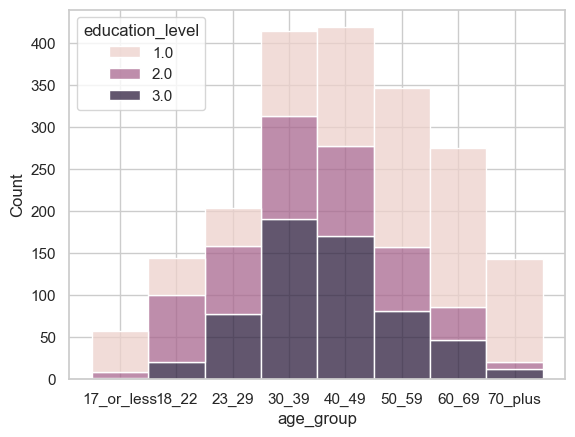

In [78]:
sns.histplot(data=df_common_renamed, x="age_group", hue="education_level", multiple="stack")

In [79]:
from scipy.stats import chi2_contingency

table=pd.crosstab(df_common_renamed["education_level"], df_common_renamed["any_digital_payment"]) 

chi2, p, dof, ex = chi2_contingency(table)
print(f"Chi2: {chi2}, p-value: {p}, dof: {dof}")

print("Expected frequencies:")
print(ex)

Chi2: 125.80699237512935, p-value: 4.801298567725146e-28, dof: 2
Expected frequencies:
[[ 97.694182   783.305818  ]
 [ 58.32819493 467.67180507]
 [ 66.97762307 537.02237693]]


In [80]:
ddf = df_common_renamed

In [81]:
# save as csv file
file = ddf.to_csv('data_cleaned.csv', index=False)

### Income Quintile

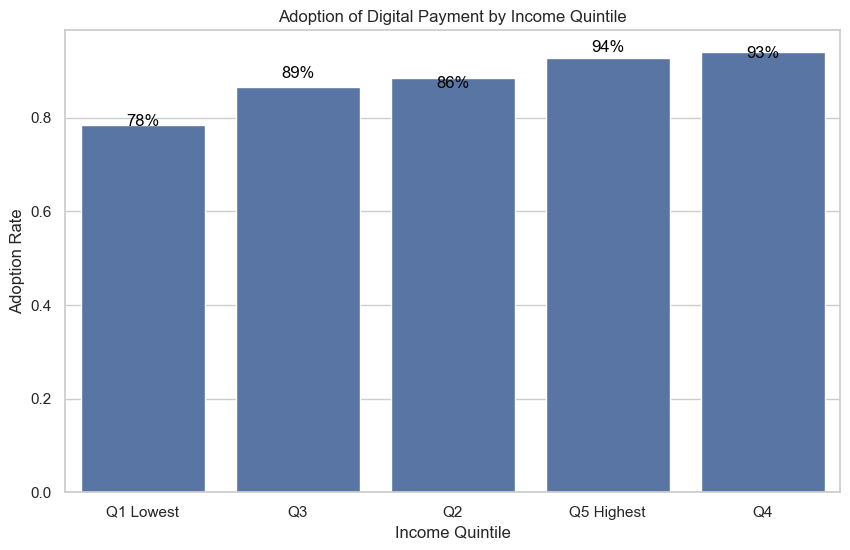

In [82]:
income_adoption = (ddf.groupby("income_quintile")['any_digital_payment'].mean().reset_index()) 
# add barplot percentage labels
for index, row in income_adoption.iterrows():
    plt.text(row.name, row.any_digital_payment, f"{row.any_digital_payment:.0%}", color='black', ha="center")

# sort values adoption rate before plotting descending
sns.barplot(data=income_adoption.sort_values("any_digital_payment", ascending=True), x="income_quintile", y="any_digital_payment")
plt.title("Adoption of Digital Payment by Income Quintile")
plt.ylabel("Adoption Rate")
plt.xlabel("Income Quintile")
plt.show()

### ANOVA Adoption rate as binary 0/1

In [84]:
from scipy import stats

# One way ANOVA for adoption rate as binary 0/1
import statsmodels.api as sm

groups = ddf.groupby("income_quintile")['any_digital_payment'].apply(list) 
groups_list = (
    ddf.groupby("income_quintile")["any_digital_payment"]
    .apply(lambda s: s.dropna().astype(float).to_numpy())
    .tolist()
)

f_val, p_val = stats.f_oneway(*groups_list)
print(f"F-value: {f_val}, P-value: {p_val}")

F-value: 15.60517245258349, P-value: 1.4017562697912279e-12


- Ho: The null hypothesis for the one-way ANOVA test is that the means of the adoption rates across all income quintiles are equal.
- Ha: The alternative hypothesis is that at least one income quintile has a different mean adoption rate.
- Significance level: Typically, a significance level (alpha) of 0.05 is used to determine whether to reject the null hypothesis

In [85]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

post_hoc_data = ddf[["income_quintile", "any_digital_payment"]].dropna()

tukey_result = pairwise_tukeyhsd(
    endog=post_hoc_data["any_digital_payment"],
    groups=post_hoc_data["income_quintile"],
    alpha=0.05
)

print(tukey_result)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2   meandiff p-adj   lower  upper  reject
----------------------------------------------------------
Q1 Lowest         Q2   0.1025 0.0002  0.0363 0.1686   True
Q1 Lowest         Q3   0.0812 0.0052  0.0169 0.1454   True
Q1 Lowest         Q4   0.1564    0.0  0.0961 0.2167   True
Q1 Lowest Q5 Highest   0.1437    0.0  0.0851 0.2024   True
       Q2         Q3  -0.0213 0.9019 -0.0868 0.0443  False
       Q2         Q4    0.054 0.1193 -0.0078 0.1157  False
       Q2 Q5 Highest   0.0413 0.3304 -0.0188 0.1014  False
       Q3         Q4   0.0753 0.0053  0.0156 0.1349   True
       Q3 Q5 Highest   0.0626 0.0268  0.0046 0.1206   True
       Q4 Q5 Highest  -0.0127 0.9676 -0.0663  0.041  False
----------------------------------------------------------


### Interpretation of Tukey HSD Results

The one-way ANOVA found that digital-payment adoption rates differ across income quintiles ($F = 15.61$, $p < 0.001$). Tukey's HSD test identifies the income groups responsible for this overall difference while controlling the family-wise error rate at $\alpha = 0.05$.

The lowest-income group (Q1) has significantly lower digital-payment adoption than every other income quintile: Q2, Q3, Q4, and Q5. The estimated differences range from 8.1 to 15.6 percentage points, with the largest gap occurring between Q1 and Q4 (15.6 percentage points).

Q3 also has significantly lower adoption than Q4 (7.5 percentage points) and Q5 (6.3 percentage points). In contrast, no statistically significant differences were found between Q2 and Q3, Q2 and Q4, Q2 and Q5, or Q4 and Q5.

Overall, the results suggest a pronounced digital-payment inclusion gap for the lowest-income quintile. Adoption rises beyond Q1, but the higher-income groups do not form a strictly increasing pattern: Q2, Q4, and Q5 are statistically similar in this sample. These results indicate an association between income position and digital-payment adoption; they do not establish that income alone causes adoption differences.

# Logistic Regression Analysis
Main statistical model for RQ1 Y= digital-payment adoption (binary outcome)

The logistic regression model will estimate the probability of digital-payment adoption as a function of income quintiles and other control variables. The model can be specified as:

$\text{logit}(\Pr(Y=1)) = \beta_0 + \beta_1 \text{Q2} + \beta_2 \text{Q3} + \beta_3 \text{Q4} + \beta_4 \text{Q5} + \mathbf{X}\boldsymbol{\gamma}$,

where $Y$ is the binary outcome for digital-payment adoption, $\text{Q2}$ to $\text{Q5}$ are dummy variables for income quintiles (with Q1 as the reference group), and $\mathbf{X}$ represents other control variables.

The coefficients $\beta_1$ to $\beta_4$ capture the effect of being in each income quintile relative to the lowest quintile (Q1) on the log-odds of digital-payment adoption, while $\boldsymbol{\gamma}$ captures the effects of the control variables.

In [17]:
# The main statistical model for RQ1: logistic regression for digital-payment adoption
# female, age, education, C(income_quintile), C(employment_status) are the predictors in the logistic regression model 

model_cols = [
    "any_digital_payment", "age", "gender",
    "income_quintile", "education_level", "employment_status"
]

ddf[model_cols].isna().sum()

any_digital_payment     0
age                    10
gender                  0
income_quintile         0
education_level         6
employment_status       0
dtype: int64

In [91]:
ddf[model_cols].head() 

,any_digital_payment,age,gender,income_quintile,education_level,employment_status
0,1.0,27.0,Female,Q4,3.0,1.0
1,1.0,30.0,Male,Q4,3.0,1.0
2,1.0,45.0,Female,Q4,3.0,1.0
3,1.0,45.0,Female,Q1 Lowest,3.0,1.0
4,1.0,39.0,Male,Q4,3.0,1.0


In [18]:
model_data = ddf[model_cols]

In [95]:
model_data.dtypes

any_digital_payment    float64
age                    float64
gender                  object
income_quintile         object
education_level        float64
employment_status      float64
dtype: object

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

model_df = model_data.dropna(subset=["any_digital_payment"]).copy()

X = model_df[["age", "gender", "income_quintile", "education_level", "employment_status"]]
y = model_df["any_digital_payment"]

numeric_features = ["age"]
categorical_features = [
    "gender", "income_quintile", "education_level", "employment_status"
]

preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  SimpleImputer(strategy='median'),
                                                  ['age']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender', 'income_quintile',
                                                   'education_level',
                                                   'employment_status'])])),
                ('logistic_regression',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [99]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["logistic_regression"].coef_[0]
odds_ratios = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
}).sort_values("odds_ratio", ascending=False)

print("Odds ratios:")
display(odds_ratios)

Test accuracy: 0.671
Test ROC-AUC: 0.789

Classification report:
              precision    recall  f1-score   support

         0.0      0.232     0.844     0.364        45
         1.0      0.971     0.649     0.778       359

    accuracy                          0.671       404
   macro avg      0.601     0.747     0.571       404
weighted avg      0.889     0.671     0.732       404

Odds ratios:


,feature,coefficient,odds_ratio
7,categorical__education_level_3.0,1.662898,5.274576
6,categorical__education_level_2.0,0.968242,2.633311
4,categorical__income_quintile_Q4,0.885316,2.423749
5,categorical__income_quintile_Q5 Highest,0.515801,1.674979
2,categorical__income_quintile_Q2,0.346946,1.414740
3,categorical__income_quintile_Q3,0.128463,1.137079
1,categorical__gender_Male,0.090967,1.095233
0,numeric__age,-0.000941,0.999059
8,categorical__employment_status_2.0,-0.505840,0.602999


### Logistic Regression Results and Interpretation

The logistic regression model predicts whether a respondent made a digital payment using age, gender, income quintile, education level, and employment status. Missing predictor values were imputed within the preprocessing pipeline, and class weights were used because digital-payment adopters substantially outnumber non-adopters.

#### Model performance

On the held-out test set, the model achieved an accuracy of 67.1% and a ROC-AUC of 0.789. The ROC-AUC indicates reasonable ability to distinguish adopters from non-adopters across possible classification thresholds.

The model identified 84.4% of non-adopters (recall = 0.844) and 64.9% of adopters (recall = 0.649). However, precision for non-adopters was 23.2%, meaning that many respondents predicted as non-adopters were actually adopters. This trade-off is expected after applying balanced class weights: the model is more attentive to the minority non-adopter group, but overall accuracy falls compared with a model that mostly predicts the majority adopter class.

#### Predictor associations

The odds-ratio estimates compare each category with its omitted reference category while holding the other included predictors constant. Education has the strongest association: respondents in education level 2 have estimated odds of adoption 2.63 times those in the reference education level, and respondents in education level 3 have estimated odds 5.27 times those in the reference level.

Income also shows meaningful differences relative to Q1, the lowest income quintile. Q4 has estimated odds of adoption 2.42 times those of Q1, while Q5 has 1.67 times the odds. Q2 and Q3 have smaller estimated increases, with odds ratios of 1.41 and 1.14, respectively. The Q4 estimate being higher than Q5 means the adjusted results are not strictly increasing across all income quintiles.

Age has a near-zero estimated association per additional year (odds ratio = 0.999), and the male-versus-female odds ratio is close to 1.10, suggesting a small adjusted gender difference in this model. Employment-status category 2 has lower estimated odds of adoption than its reference category (odds ratio = 0.60).

#### Conclusion and limitations

Overall, education level and income quintile are the strongest predictors of digital-payment adoption among the variables included. The model shows useful discriminatory ability, but its low precision for non-adopters means it should not be used as a stand-alone screening tool. These estimates describe adjusted associations, not causal effects, and this scikit-learn model does not provide p-values or confidence intervals; a statsmodels logistic regression would be needed for formal statistical-inference claims.

## Logistic Regression for Statistical Inference

This model uses complete cases only, so p-values and confidence intervals are calculated from respondents with observed values for every model variable. It is separate from the class-weighted scikit-learn model, which is retained for prediction evaluation.

Reference groups are female, Q1 (lowest income), education level 1, and employment-status code 1. Odds ratios greater than 1 indicate higher estimated odds of digital-payment adoption than the relevant reference group; odds ratios below 1 indicate lower estimated odds.

In [100]:
import statsmodels.formula.api as smf

inference_data = model_data.dropna().copy()

inference_formula = (
    'any_digital_payment ~ age + '
    'C(gender, Treatment(reference="Female")) + '
    'C(income_quintile, Treatment(reference="Q1 Lowest")) + '
    'C(education_level, Treatment(reference=1.0)) + '
    'C(employment_status, Treatment(reference=1.0))'
 )

inference_model = smf.logit(
    formula=inference_formula,
    data=inference_data
).fit(disp=False, cov_type="HC3")

confidence_intervals = inference_model.conf_int()
inference_results = pd.DataFrame({
    "coefficient": inference_model.params,
    "odds_ratio": np.exp(inference_model.params),
    "ci_lower": np.exp(confidence_intervals[0]),
    "ci_upper": np.exp(confidence_intervals[1]),
    "p_value": inference_model.pvalues
})

print(f"Complete-case sample size: {len(inference_data)}")
print(inference_model.summary())
display(inference_results.round(3))

Complete-case sample size: 2002
                            Logit Regression Results                           
Dep. Variable:     any_digital_payment   No. Observations:                 2002
Model:                           Logit   Df Residuals:                     1992
Method:                            MLE   Df Model:                            9
Date:                 Tue, 15 Sep 2026   Pseudo R-squ.:                  0.1128
Time:                         22:29:29   Log-Likelihood:                -620.63
converged:                        True   LL-Null:                       -699.52
Covariance Type:                   HC3   LLR p-value:                 2.155e-29
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                 

,coefficient,odds_ratio,ci_lower,ci_upper,p_value
Intercept,1.308,3.699,2.104,6.502,0.000
"C(gender, Treatment(reference=""Female""))[T.Male]",0.119,1.126,0.837,1.516,0.432
"C(income_quintile, Treatment(reference=""Q1 Lowest""))[T.Q2]",0.479,1.614,1.032,2.523,0.036
"C(income_quintile, Treatment(reference=""Q1 Lowest""))[T.Q3]",0.062,1.064,0.694,1.631,0.778
"C(income_quintile, Treatment(reference=""Q1 Lowest""))[T.Q4]",0.796,2.217,1.347,3.649,0.002
"C(income_quintile, Treatment(reference=""Q1 Lowest""))[T.Q5 Highest]",0.422,1.525,0.971,2.395,0.067
"C(education_level, Treatment(reference=1.0))[T.2.0]",1.160,3.190,2.121,4.800,0.000
"C(education_level, Treatment(reference=1.0))[T.3.0]",1.946,6.998,4.063,12.053,0.000
"C(employment_status, Treatment(reference=1.0))[T.2.0]",-0.421,0.657,0.472,0.913,0.012
age,-0.002,0.998,0.989,1.006,0.619


### Interpretation of Inferential Logistic Regression

The overall logistic regression model is statistically significant (likelihood-ratio test $p < 0.001$), indicating that the predictors jointly improve the explanation of digital-payment adoption compared with an intercept-only model. The model has a pseudo-$R^2$ of 0.113, so the included demographic and socioeconomic variables explain part, but not all, of the variation in adoption.

Holding the other variables constant, income quintile is associated with adoption for some groups. Compared with Q1 (the lowest quintile), Q2 respondents have 1.61 times higher odds of adoption (95% CI: 1.03 to 2.52, $p = 0.036$), and Q4 respondents have 2.22 times higher odds (95% CI: 1.35 to 3.65, $p = 0.002$). The Q3 comparison is not statistically significant ($p = 0.778$), and Q5 is not significant at the 5% level ($p = 0.067$). Thus, the adjusted income pattern is not strictly increasing across quintiles.

Education is the strongest observed predictor. Relative to education level 1, education level 2 is associated with 3.19 times higher odds of adoption (95% CI: 2.12 to 4.80, $p < 0.001$), while education level 3 is associated with 7.00 times higher odds (95% CI: 4.06 to 12.05, $p < 0.001$).

Employment-status category 2 has lower estimated odds of adoption than category 1 (OR = 0.66, 95% CI: 0.47 to 0.91, $p = 0.012$). Gender and age are not statistically significant predictors in this specification: the confidence intervals for their odds ratios include 1.

These findings are adjusted associations based on complete cases and do not establish causal effects. The results should be interpreted alongside the survey design and the meaning of the coded education and employment categories.

## Model Results Visualizations

The first two panels evaluate predictive performance on the held-out test set. The forest plot shows adjusted odds ratios and 95% confidence intervals from the `statsmodels` logistic regression; points to the right of 1 indicate higher odds of digital-payment adoption, while points to the left indicate lower odds.

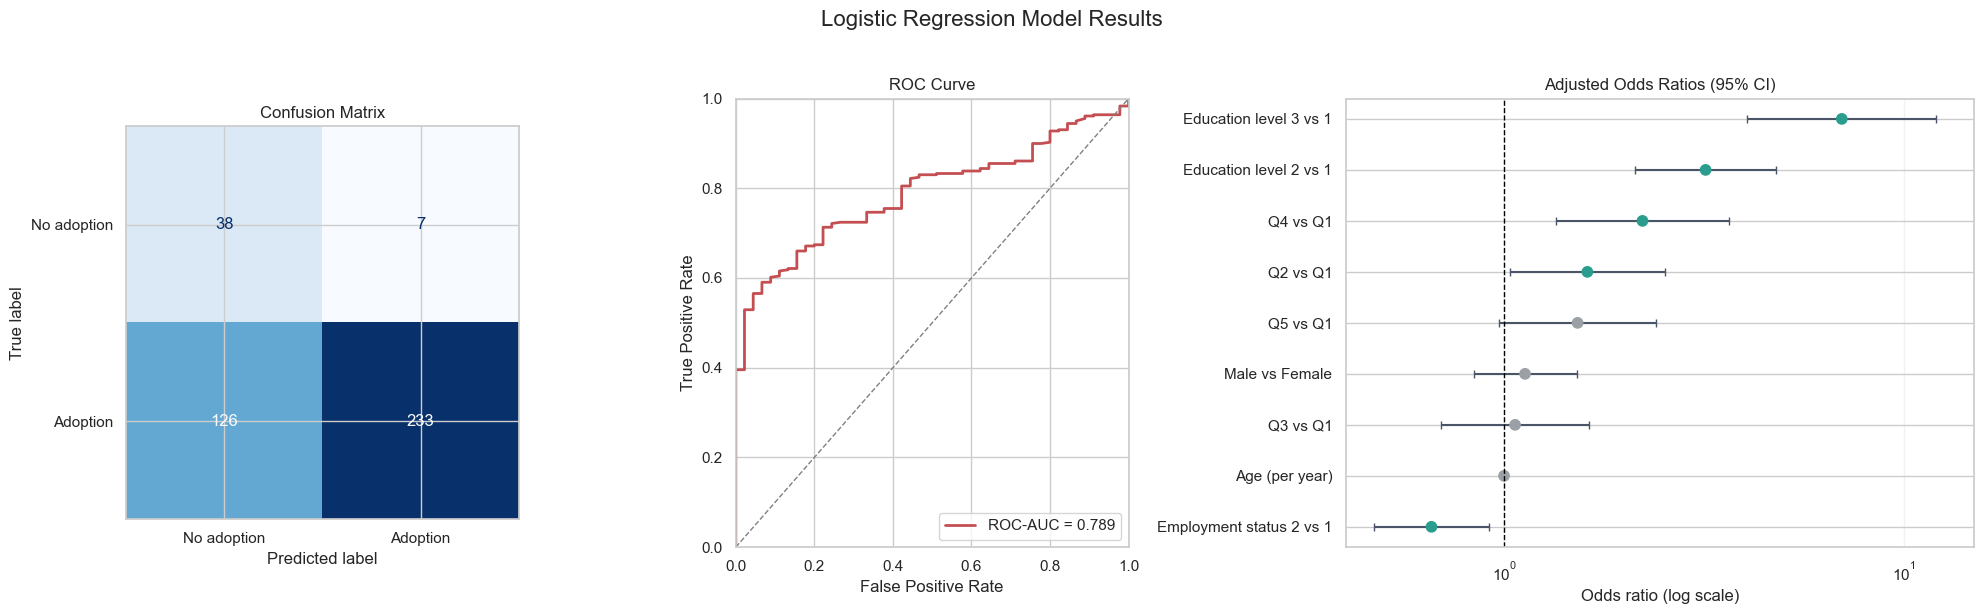

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plot_results = inference_results.drop(index="Intercept").copy()
plot_results["label"] = [
    "Male vs Female",
    "Q2 vs Q1",
    "Q3 vs Q1",
    "Q4 vs Q1",
    "Q5 vs Q1",
    "Education level 2 vs 1",
    "Education level 3 vs 1",
    "Employment status 2 vs 1",
    "Age (per year)"
]
plot_results = plot_results.sort_values("odds_ratio")

fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"width_ratios": [1, 1, 1.6]})

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No adoption", "Adoption"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, color="#C44E52", linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set(
    title="ROC Curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    xlim=(0, 1),
    ylim=(0, 1)
)
axes[1].legend(loc="lower right")

significant = plot_results["p_value"] < 0.05
colors = np.where(significant, "#2A9D8F", "#9AA0A6")
axes[2].errorbar(
    plot_results["odds_ratio"],
    plot_results["label"],
    xerr=[
        plot_results["odds_ratio"] - plot_results["ci_lower"],
        plot_results["ci_upper"] - plot_results["odds_ratio"],
    ],
    fmt="none",
    ecolor="#4A5568",
    capsize=3,
    zorder=1,
)
axes[2].scatter(
    plot_results["odds_ratio"],
    plot_results["label"],
    color=colors,
    s=55,
    zorder=2,
)
axes[2].axvline(1, color="black", linestyle="--", linewidth=1)
axes[2].set_xscale("log")
axes[2].set(
    title="Adjusted Odds Ratios (95% CI)",
    xlabel="Odds ratio (log scale)",
    ylabel="",
    xlim=(0.4, 15)
)
axes[2].grid(axis="x", alpha=0.25)

fig.suptitle("Logistic Regression Model Results", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

rf_X_train, rf_X_test, rf_y_train, rf_y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
 )

rf_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), ["age"]),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), ["gender", "income_quintile", "education_level", "employment_status"]),
])

rf_model = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )),
])

rf_model.fit(rf_X_train, rf_y_train)
rf_y_pred = rf_model.predict(rf_X_test)
rf_y_prob = rf_model.predict_proba(rf_X_test)[:, 1]

print(f"Test accuracy: {accuracy_score(rf_y_test, rf_y_pred):.3f}")
print(f"Test ROC-AUC: {roc_auc_score(rf_y_test, rf_y_prob):.3f}")
print("\nClassification report:")
print(classification_report(rf_y_test, rf_y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(rf_y_test, rf_y_pred))

rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
rf_importances = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.named_steps["classifier"].feature_importances_,
}).sort_values("importance", ascending=False)

print("\nTop feature importances:")
display(rf_importances.head(10))

Test accuracy: 0.802
Test ROC-AUC: 0.742

Classification report:
              precision    recall  f1-score   support

         0.0      0.284     0.511     0.365        45
         1.0      0.932     0.838     0.883       359

    accuracy                          0.802       404
   macro avg      0.608     0.675     0.624       404
weighted avg      0.860     0.802     0.825       404

Confusion matrix:
 [[ 23  22]
 [ 58 301]]

Top feature importances:


,feature,importance
0,numeric__age,0.506897
8,categorical__education_level_1.0,0.121232
10,categorical__education_level_3.0,0.074083
3,categorical__income_quintile_Q1 Lowest,0.038697
9,categorical__education_level_2.0,0.033930
5,categorical__income_quintile_Q3,0.033771
6,categorical__income_quintile_Q4,0.032763
12,categorical__employment_status_2.0,0.028796
1,categorical__gender_Female,0.027743
7,categorical__income_quintile_Q5 Highest,0.027740


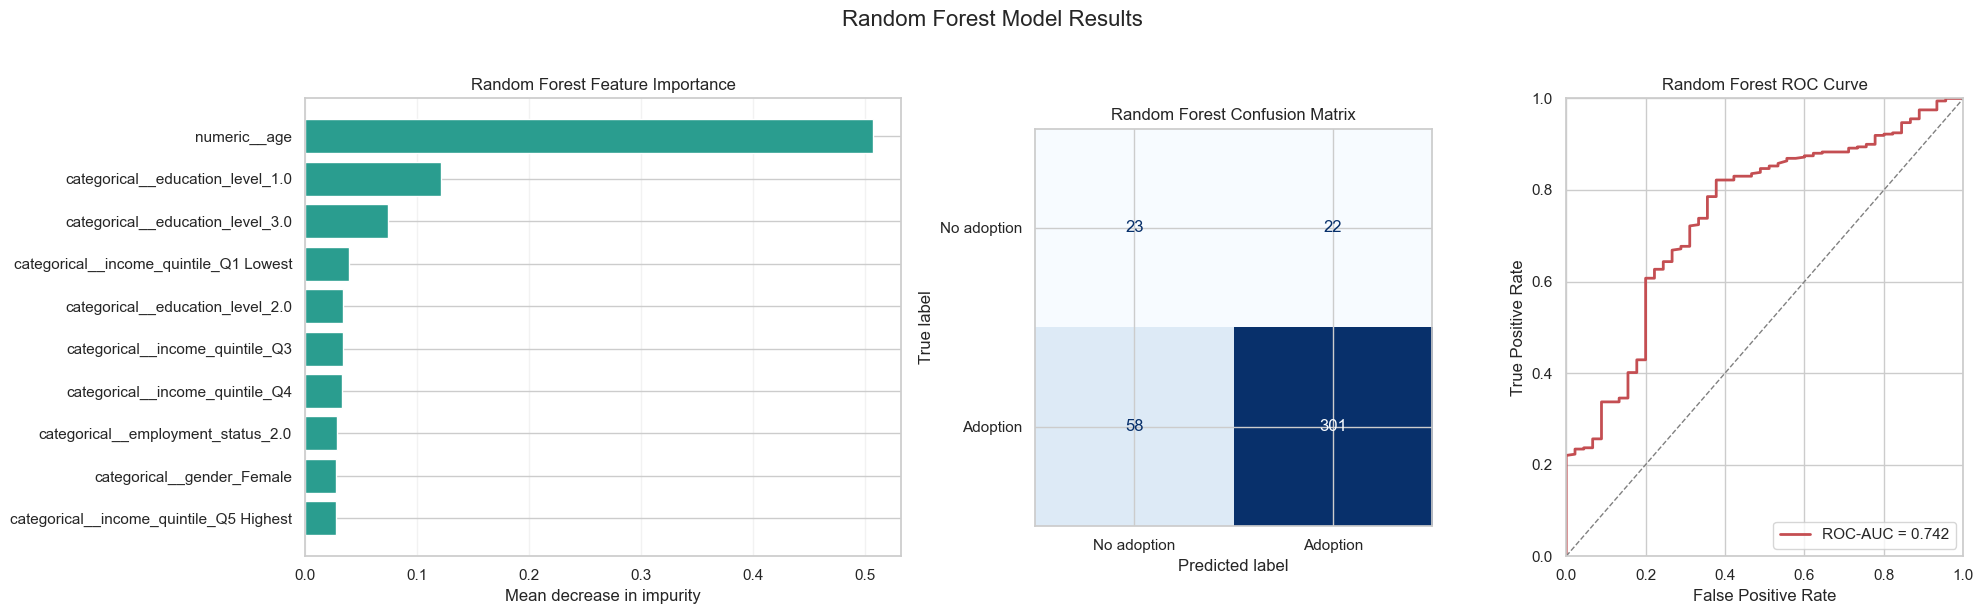

In [104]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

top_features = rf_importances.head(10).sort_values("importance")
rf_fpr, rf_tpr, _ = roc_curve(rf_y_test, rf_y_prob)
rf_roc_auc = roc_auc_score(rf_y_test, rf_y_prob)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"width_ratios": [1.5, 1, 1]})

axes[0].barh(top_features["feature"], top_features["importance"], color="#2A9D8F")
axes[0].set(
    title="Random Forest Feature Importance",
    xlabel="Mean decrease in impurity",
    ylabel="",
)
axes[0].grid(axis="x", alpha=0.25)

ConfusionMatrixDisplay.from_predictions(
    rf_y_test,
    rf_y_pred,
    display_labels=["No adoption", "Adoption"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Random Forest Confusion Matrix")

axes[2].plot(
    rf_fpr,
    rf_tpr,
    color="#C44E52",
    linewidth=2,
    label=f"ROC-AUC = {rf_roc_auc:.3f}",
)
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[2].set(
    title="Random Forest ROC Curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[2].legend(loc="lower right")

fig.suptitle("Random Forest Model Results", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Random Forest Model Results Visualization
 - Top 10 Features by Importance bar chart 
 - Confusion matrix 
 - ROC curve with ROC-AUC score 0.742 

 Age is the dominant feature followed by education level.

## XGBoost Classifier

XGBoost is evaluated as a nonlinear alternative to logistic regression and Random Forest. The model uses the same predictors and a stratified train-test split. Missing values are imputed and categorical variables are one-hot encoded inside the pipeline, while `scale_pos_weight` addresses the minority non-adopter class.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

xgb_X_train, xgb_X_test, xgb_y_train, xgb_y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
 )

xgb_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), ["age"]),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), ["gender", "income_quintile", "education_level", "employment_status"]),
])

class_ratio = (xgb_y_train == 0).sum() / (xgb_y_train == 1).sum()
xgb_model = Pipeline([
    ("preprocessor", xgb_preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=class_ratio,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )),
])

xgb_model.fit(xgb_X_train, xgb_y_train)
xgb_y_pred = xgb_model.predict(xgb_X_test)
xgb_y_prob = xgb_model.predict_proba(xgb_X_test)[:, 1]

print(f"Test accuracy: {accuracy_score(xgb_y_test, xgb_y_pred):.3f}")
print(f"Test ROC-AUC: {roc_auc_score(xgb_y_test, xgb_y_prob):.3f}")
print("\nClassification report:")
print(classification_report(xgb_y_test, xgb_y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(xgb_y_test, xgb_y_pred))

Test accuracy: 0.705
Test ROC-AUC: 0.789

Classification report:
              precision    recall  f1-score   support

         0.0      0.232     0.711     0.350        45
         1.0      0.951     0.705     0.810       359

    accuracy                          0.705       404
   macro avg      0.592     0.708     0.580       404
weighted avg      0.871     0.705     0.758       404

Confusion matrix:
 [[ 32  13]
 [106 253]]


### XGBoost Model Results Visualization

The plots below show XGBoost performance on the held-out test set. Feature importance is gain-based: larger values indicate that a feature contributed more to improving decision-tree splits.

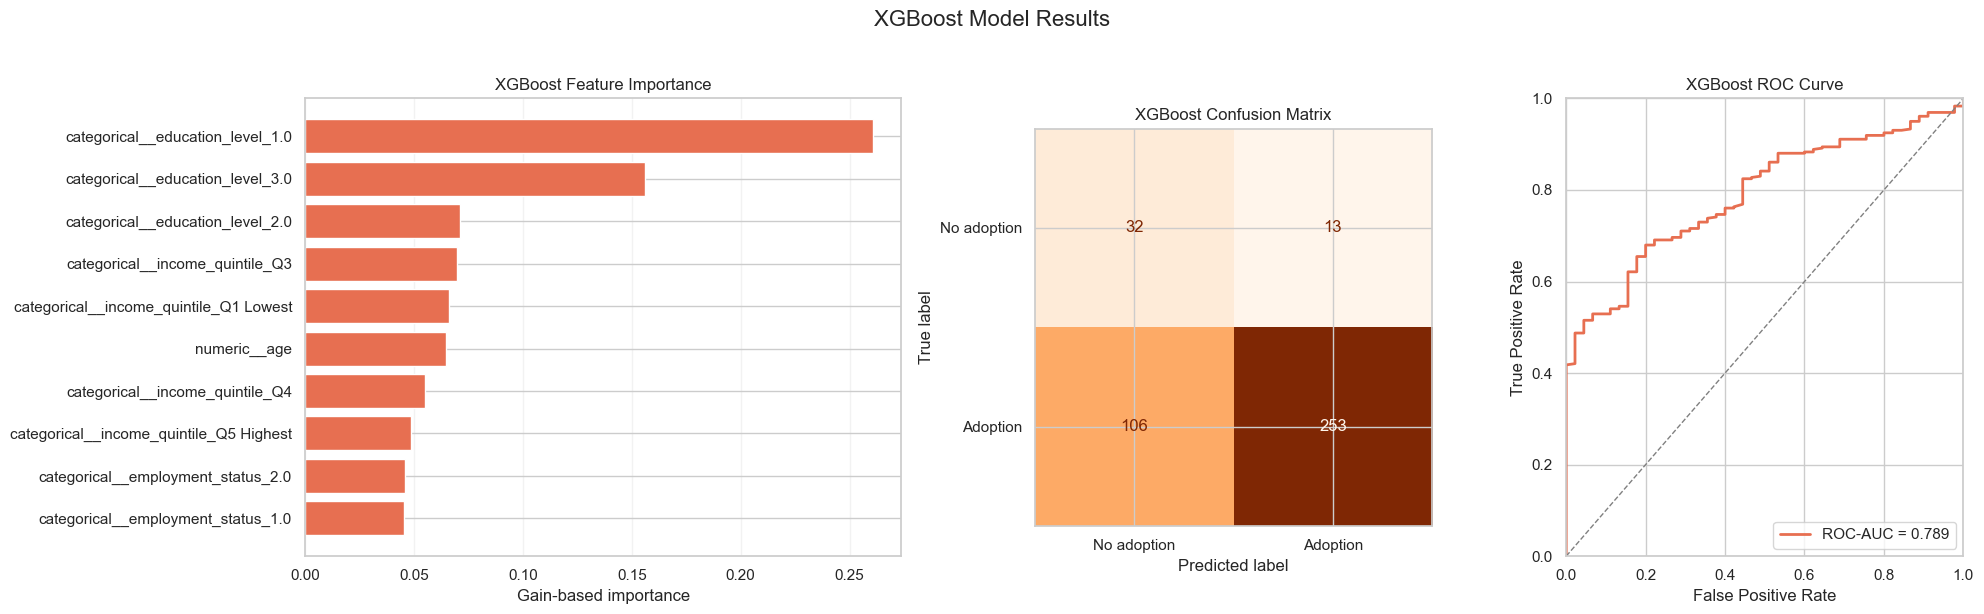

,feature,importance
8,categorical__education_level_1.0,0.260610
10,categorical__education_level_3.0,0.156206
9,categorical__education_level_2.0,0.071158
5,categorical__income_quintile_Q3,0.069950
3,categorical__income_quintile_Q1 Lowest,0.066220
0,numeric__age,0.064777
6,categorical__income_quintile_Q4,0.055140
7,categorical__income_quintile_Q5 Highest,0.048516
12,categorical__employment_status_2.0,0.045771
11,categorical__employment_status_1.0,0.045397


In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

xgb_feature_names = xgb_model.named_steps["preprocessor"].get_feature_names_out()
xgb_importances = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_model.named_steps["classifier"].feature_importances_,
}).sort_values("importance", ascending=False)

top_xgb_features = xgb_importances.head(10).sort_values("importance")
xgb_fpr, xgb_tpr, _ = roc_curve(xgb_y_test, xgb_y_prob)
xgb_roc_auc = roc_auc_score(xgb_y_test, xgb_y_prob)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"width_ratios": [1.5, 1, 1]})

axes[0].barh(top_xgb_features["feature"], top_xgb_features["importance"], color="#E76F51")
axes[0].set(
    title="XGBoost Feature Importance",
    xlabel="Gain-based importance",
    ylabel="",
)
axes[0].grid(axis="x", alpha=0.25)

ConfusionMatrixDisplay.from_predictions(
    xgb_y_test,
    xgb_y_pred,
    display_labels=["No adoption", "Adoption"],
    cmap="Oranges",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("XGBoost Confusion Matrix")

axes[2].plot(
    xgb_fpr,
    xgb_tpr,
    color="#E76F51",
    linewidth=2,
    label=f"ROC-AUC = {xgb_roc_auc:.3f}",
)
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[2].set(
    title="XGBoost ROC Curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[2].legend(loc="lower right")

fig.suptitle("XGBoost Model Results", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

display(xgb_importances.head(10))

Education level indicators  are the most influential XgBoost features followed by income quintile and age.